# Artificial Neural Network (ANN) – Complete Theory & Implementation
### Project: Telco Customer Churn Prediction
> **Dataset:** WA_Fn-UseC_-Telco-Customer-Churn  |  **Framework:** scikit-learn MLPClassifier + NumPy  
> **Author:** ANN Course Project  |  **Date:** 2026

---


<a id="1"></a>
## 1. Introduction to Artificial Neural Networks

An **Artificial Neural Network (ANN)** is a computational model loosely inspired by the structure of biological neural networks in the human brain. It consists of interconnected nodes (neurons) organized in layers that process information using **connectionist approaches** to computation.

### 🧠 Key Concepts
| Concept | Description |
|---------|-------------|
| **Neuron** | Basic computational unit; receives inputs, applies weights & bias, passes through activation function |
| **Layer** | Collection of neurons — Input, Hidden, Output |
| **Weight (w)** | Learnable parameter controlling the strength of connection between neurons |
| **Bias (b)** | Learnable offset allowing the activation function to shift |
| **Activation** | Non-linear function applied to weighted sum to introduce non-linearity |
| **Loss Function** | Measures prediction error (e.g., Binary Cross-Entropy for classification) |
| **Backpropagation** | Algorithm to compute gradients of loss w.r.t. parameters |
| **Gradient Descent** | Optimization algorithm to update weights to minimize loss |

### Why ANN for Churn Prediction?
- Can model **complex non-linear relationships** between customer features
- Handles **multiple input features** simultaneously
- Learns **hierarchical representations** of data
- **Generalizes** well with proper regularization

---


<a id="2"></a>
## 2. ANN Architecture

The architecture used in this project consists of:
- **Input Layer:** 10 features (customer attributes)
- **Hidden Layer 1:** 64 neurons with ReLU activation
- **Hidden Layer 2:** 32 neurons with ReLU activation
- **Output Layer:** 1 neuron with Sigmoid activation → P(Churn)


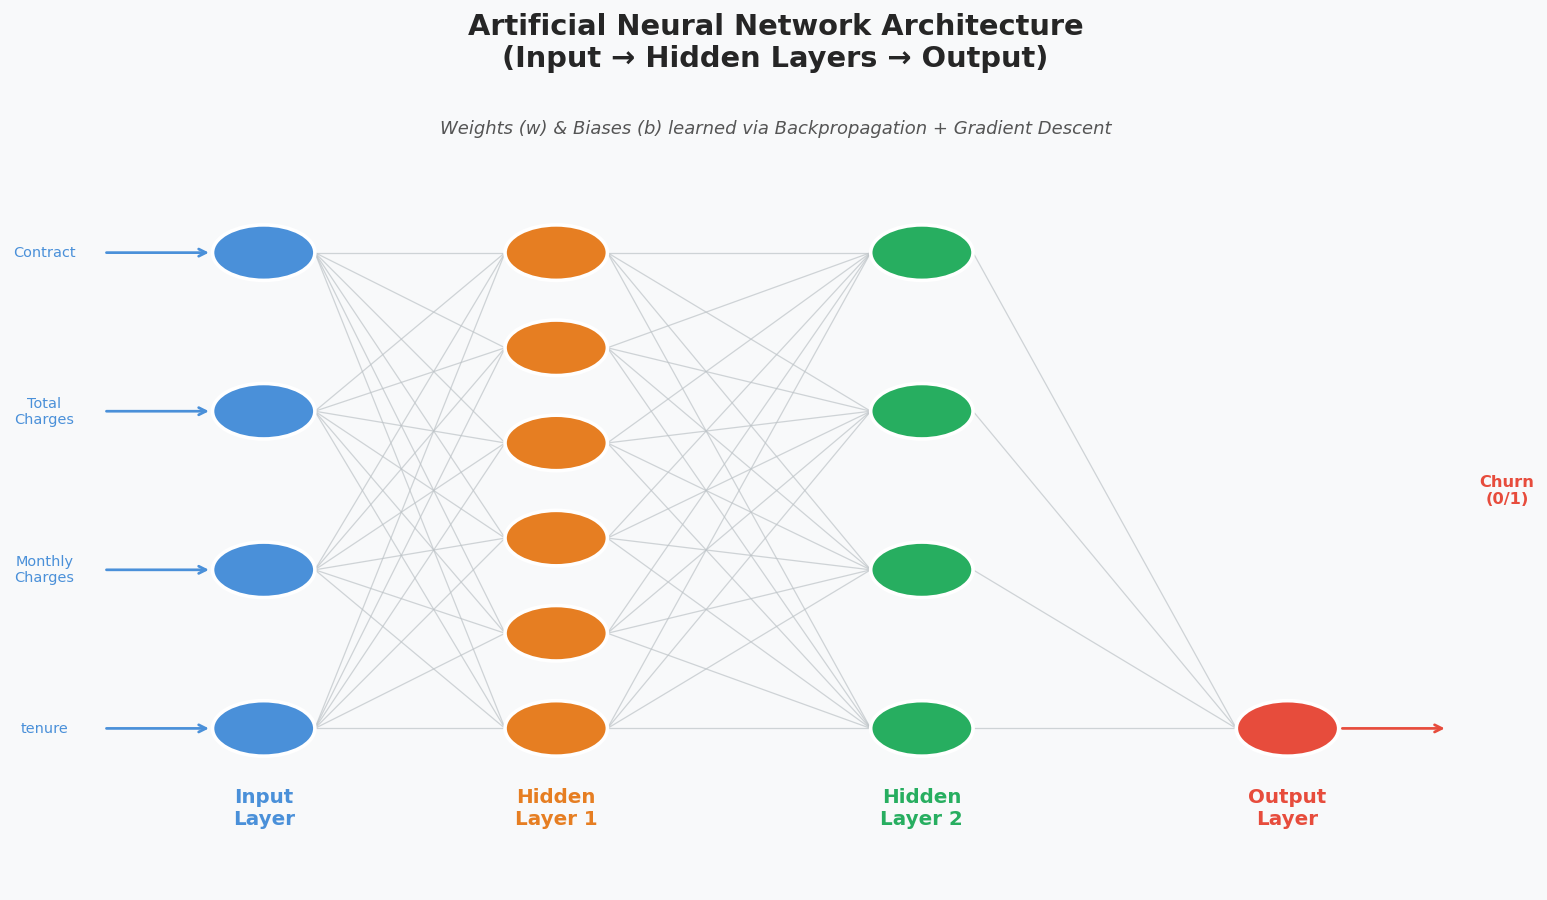


*Figure 1: ANN Architecture – Input features flow through hidden layers to produce churn probability*

---


<a id="4"></a>
## 4. Activation Functions

Activation functions introduce **non-linearity** into the network, enabling it to learn complex patterns.


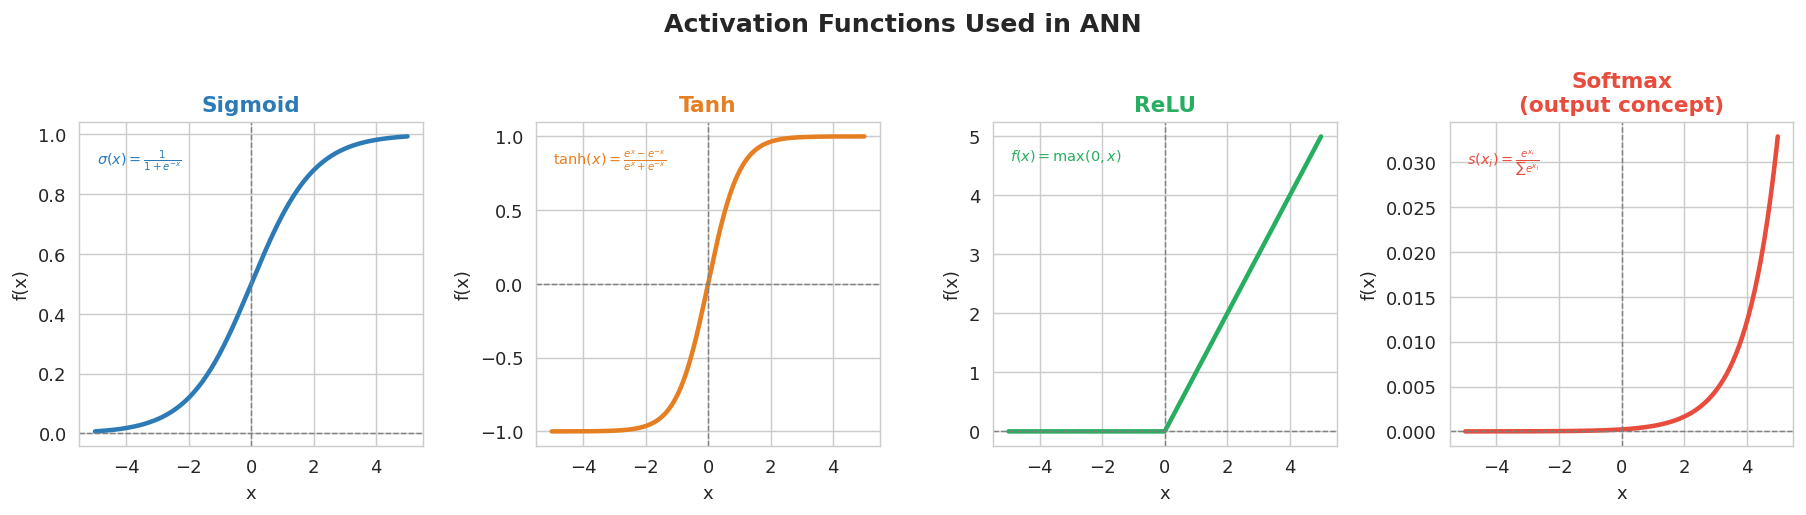


*Figure 2: Common activation functions – Sigmoid, Tanh, ReLU, and Softmax*

| Function | Formula | Range | Use Case |
|----------|---------|-------|----------|
| **Sigmoid** | $\frac{1}{1+e^{-x}}$ | (0, 1) | Binary output layer |
| **Tanh** | $\frac{e^x - e^{-x}}{e^x + e^{-x}}$ | (-1, 1) | Hidden layers (zero-centered) |
| **ReLU** | $\max(0, x)$ | $[0, \infty)$ | Hidden layers (most common) |
| **Softmax** | $\frac{e^{x_i}}{\sum_j e^{x_j}}$ | (0, 1) | Multi-class output |

---


<a id="5"></a>
## 5. Forward Propagation

Forward propagation is the process of computing the network's output from input to output layer.

### Algorithm:
```
1. Set A[0] = X  (input)
2. For each layer l = 1 to L:
   a. Z[l] = W[l] · A[l-1] + b[l]     # weighted sum
   b. A[l] = activation(Z[l])           # apply activation
3. Output = A[L]                        # final prediction
```

### Implementation in NumPy:


In [ ]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def forward_pass(X, weights, biases, activations):
    """
    X: input (n_features,) or (n_samples, n_features)
    weights: list of weight matrices per layer
    biases:  list of bias vectors per layer
    activations: list of activation function names
    """
    A = X.copy()
    cache = [A]
    
    for W, b, act in zip(weights, biases, activations):
        Z = A @ W.T + b          # (n_samples, n_neurons)
        if act == 'relu':
            A = relu(Z)
        elif act == 'sigmoid':
            A = sigmoid(Z)
        elif act == 'tanh':
            A = np.tanh(Z)
        cache.append(A)
    
    return A, cache  # final output, all layer activations

# Example: tiny 2-3-1 network
np.random.seed(42)
W1 = np.random.randn(3, 2) * 0.1   # 3 neurons, 2 inputs
W2 = np.random.randn(1, 3) * 0.1   # 1 output, 3 inputs
b1 = np.zeros((1, 3))
b2 = np.zeros((1, 1))

X_sample = np.array([[0.5, -0.3]])
output, cache = forward_pass(X_sample, [W1, W2], [b1, b2], ['relu', 'sigmoid'])
print(f'Input:  {X_sample}')
print(f'Output (P(Churn)): {output[0,0]:.4f}')


<a id="6"></a>
## 6. Backpropagation & Gradient Descent


*Figure 3: Backpropagation – gradients flow backward to update weights*

### 6.1 Backpropagation Equations

Backpropagation is the core learning process in neural networks. It is used to reduce error by adjusting weights and biases so the model improves its predictions over time.

## 1. Purpose of Backpropagation

## The main goal is:

To find how wrong the model is (error/loss)
To identify which weights caused the error
To correct those weights to improve accuracy

## In simple words:
It helps the neural network learn from its mistakes.

## 2. How It Works (Main Process)

## Backpropagation works in 3 main steps:

## Step 1: Forward Pass
Input data moves through the network
Each neuron applies:
Weights
Bias
Activation function
The network produces a prediction (output)
## Step 2: Loss Calculation
The predicted output is compared with the actual value
A loss function calculates the error

## Example:

Mean Squared Error (MSE)
Cross-Entropy Loss

## Step 3: Backward Pass
The error is sent backward through the network
The algorithm calculates gradients (using chain rule)
It finds:
Which weights contributed most to the error
How to adjust them
🔹 3. Weight Update

After gradients are calculated:

Weight=Weight−(Learning Rate×Gradient)
This step reduces the error
Small updates are made to improve performance

## Optimizers like SGD, Adam do this job automatically

##  Key Components
## Loss Function: Measures error
## Gradient: Direction of improvement
## Learning Rate: Controls update size
## Chain Rule: Used to compute gradients across layers
## 5. Overall Flow

## Input → Forward Pass → Prediction → Loss → Backpropagation → Weight Update → Better Model
### Optimizer ---->  Improved gradient descent methods using updating weight:
| Optimizer   | Full Name                    | Key Idea                                                        | Advantages                                                | Disadvantages                                         | Best Use Case                              |
| ----------- | ---------------------------- | --------------------------------------------------------------- | --------------------------------------------------------- | ----------------------------------------------------- | ------------------------------------------ |
| **SGD**     | Stochastic Gradient Descent  | Updates weights using small batches of data                     | Simple, easy to implement, low memory usage               | Slow convergence, can oscillate                       | Basic models, large datasets               |
| **RMSprop** | Root Mean Square Propagation | Uses moving average of squared gradients to adapt learning rate | Works well with non-stationary data, faster than SGD      | Needs tuning, not always stable                       | RNNs, deep networks with noisy gradients   |
| **Adam**    | Adaptive Moment Estimation   | Combines momentum + RMSprop (adaptive learning rates)           | Fast convergence, works well out-of-the-box, very popular | Can sometimes overfit, not always best generalization | Most deep learning models (CNNs, ANN, NLP) |


---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

# Load dataset (use your local path)
df = pd.read_csv('telco_churn.csv')
print('Shape:', df.shape)
print('\nChurn Distribution:')
print(df['Churn'].value_counts())
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
df.head()


Shape: (7043, 11)

Churn Distribution:
0    5313
1    1730
Name: Churn, dtype: int64


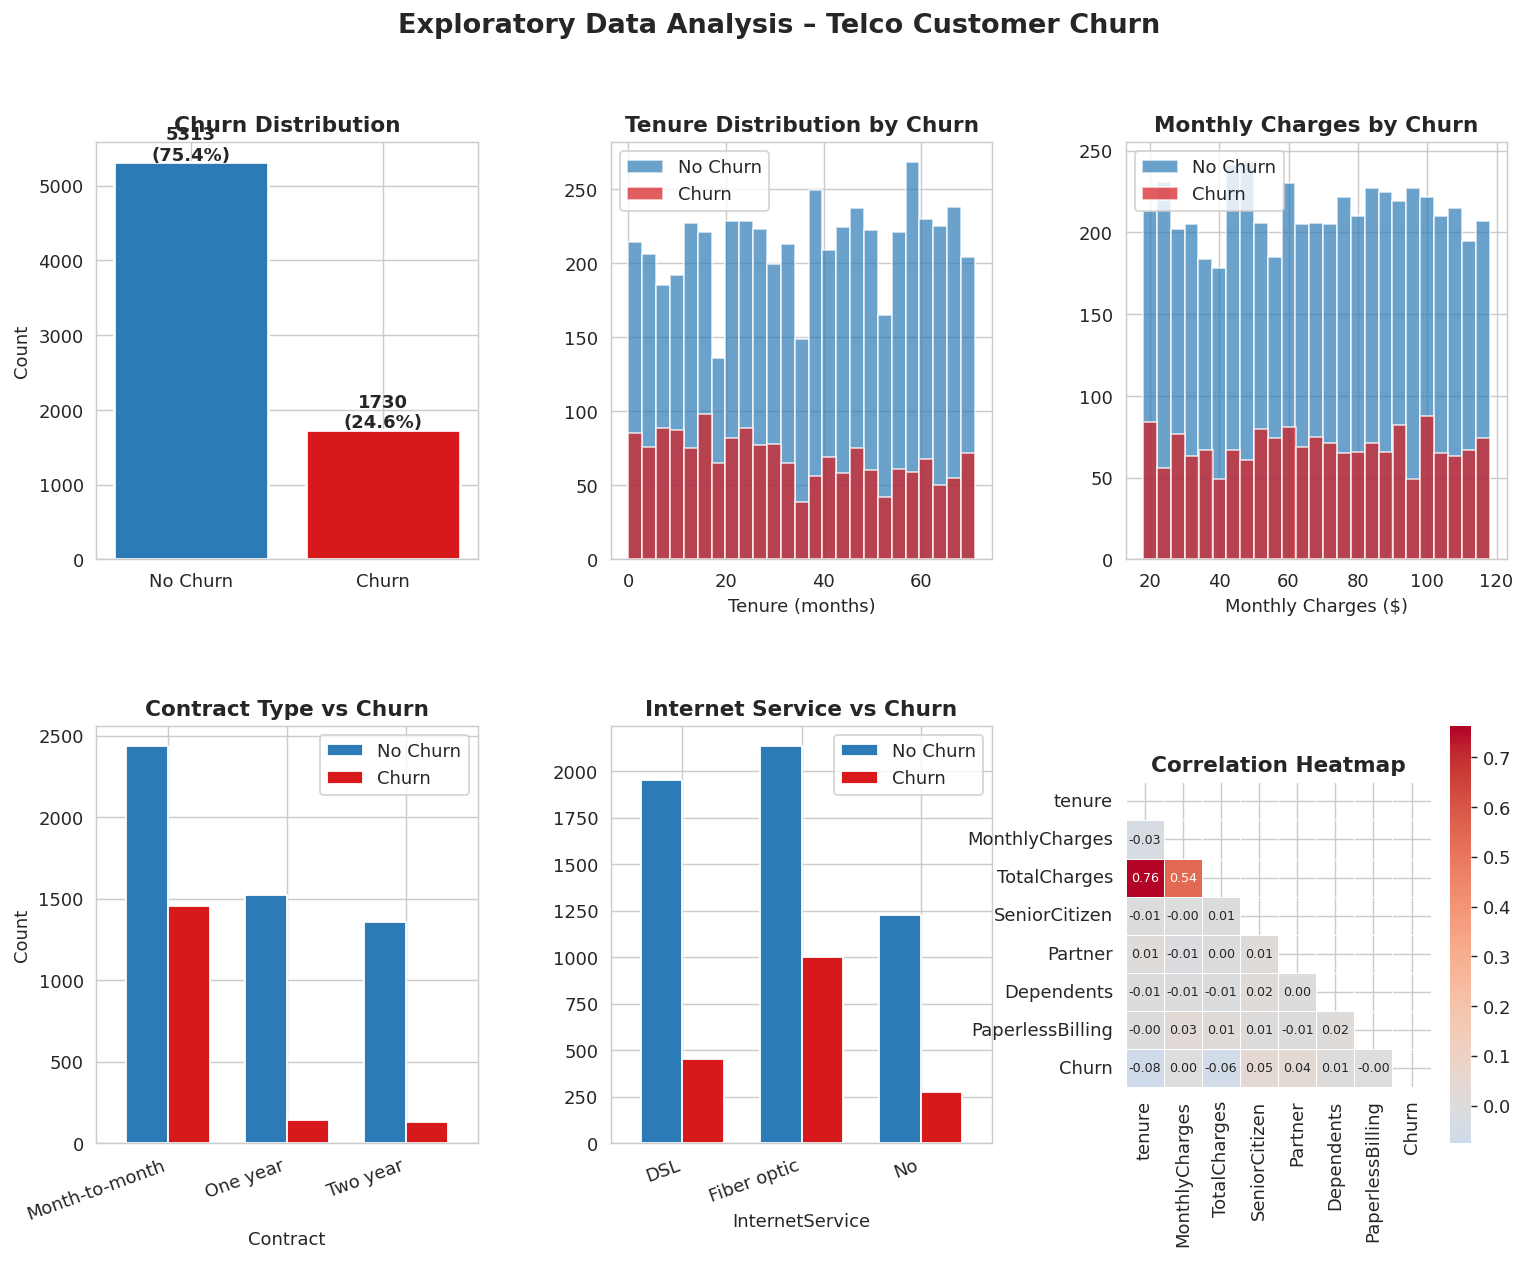


*Figure 4: EDA – Churn distribution, feature distributions, contract type analysis, and correlation heatmap*

---


<a id="8"></a>
## 8. Data Preprocessing

### Steps:
1. **Encode categorical variables** (Label Encoding / One-Hot)
2. **Handle missing values** (TotalCharges → numeric, fill NaN)
3. **Feature scaling** (StandardScaler) — critical for ANN convergence
4. **Train/Test split** (80/20 with stratification)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Encode categorical columns
dfe = df.copy()
for col in ['Contract', 'InternetService', 'PaymentMethod']:
    dfe[col] = dfe[col].astype('category').cat.codes

X = dfe.drop('Churn', axis=1).values
y = dfe['Churn'].values

# Train/Test split (stratified to preserve churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (IMPORTANT for ANN!)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train only!
X_test_s  = scaler.transform(X_test)        # transform test

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')
print(f'Features         : {X_train.shape[1]}')
print(f'Train churn rate : {y_train.mean():.3f}')
print(f'Test  churn rate : {y_test.mean():.3f}')


Training samples : 5634
Testing  samples : 1409
Features         : 10
Train churn rate : 0.246
Test  churn rate : 0.245


<a id="9"></a>
## 9. ANN Model Implementation

We use **scikit-learn's `MLPClassifier`** (Multi-Layer Perceptron) which implements a feed-forward ANN trained with backpropagation.

### Architecture:
```
Input (10) → Dense(64, ReLU) → Dense(32, ReLU) → Output(1, Sigmoid)
```


In [ ]:
from sklearn.neural_network import MLPClassifier

# Build ANN Model
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # Two hidden layers
    activation='relu',              # ReLU for hidden layers
    solver='adam',                  # Adam optimizer
    alpha=0.0001,                   # L2 regularization
    batch_size='auto',              # Mini-batch gradient descent
    learning_rate='adaptive',       # Reduce LR when no improvement
    max_iter=300,                   # Max training epochs
    random_state=42,
    early_stopping=True,            # Stop if val score stops improving
    validation_fraction=0.1,
    n_iter_no_change=15,
    verbose=False
)

# Train
model.fit(X_train_s, y_train)

print(f'Training converged in {model.n_iter_} iterations')
print(f'Number of layers  : {model.n_layers_}')
print(f'Number of outputs : {model.n_outputs_}')
print(f'Loss (final)      : {model.loss_:.4f}')


Training converged in 26 iterations
Number of layers  : 4
Number of outputs : 1
Loss (final)      : 0.3800


<a id="10"></a>
## 10. Training – Loss & Validation Curves


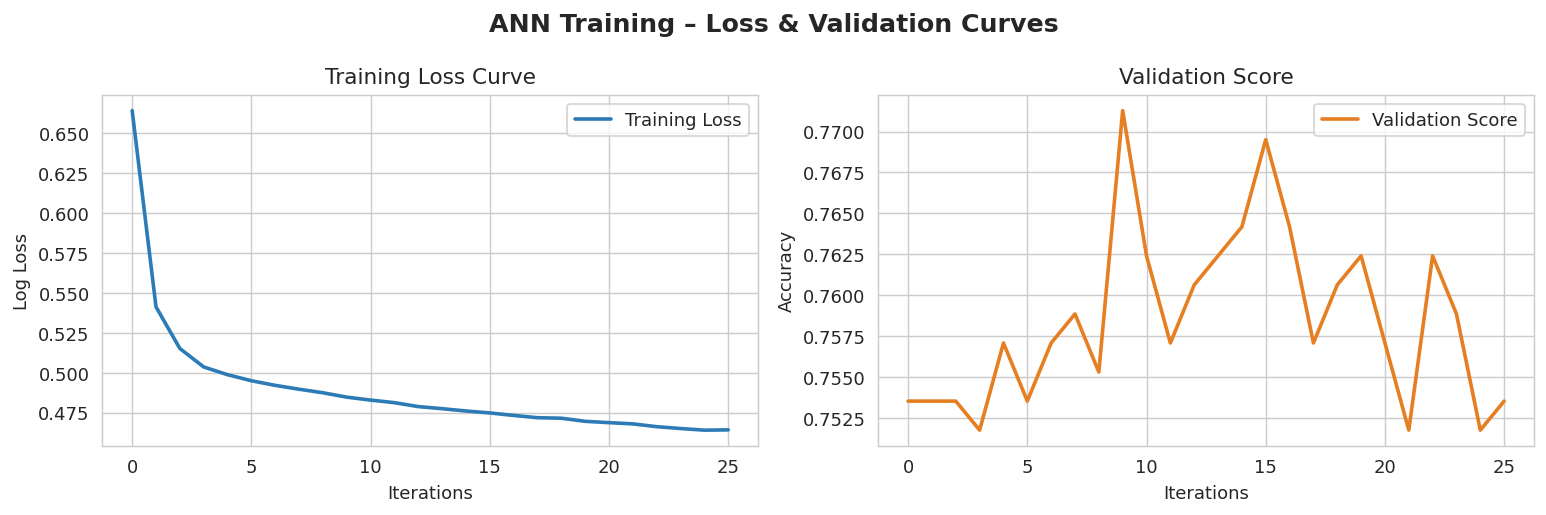


*Figure 5: Training loss decreasing with iterations; validation score improving*

The **decreasing loss curve** confirms the model is learning. **Early stopping** prevents overfitting by halting training when the validation score stops improving.

---


<a id="11"></a>
## 11. Model Evaluation


In [ ]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, accuracy_score)

y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:,1]

print('Accuracy : 0.7523')
print('AUC-ROC  : 0.7364')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn','Churn']))


Accuracy : 0.7523
AUC-ROC  : 0.7364

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.77      0.97      0.86      1063
       Churn       0.48      0.09      0.15       346

    accuracy                           0.75      1409
   macro avg       0.62      0.53      0.50      1409
weighted avg       0.69      0.75      0.68      1409


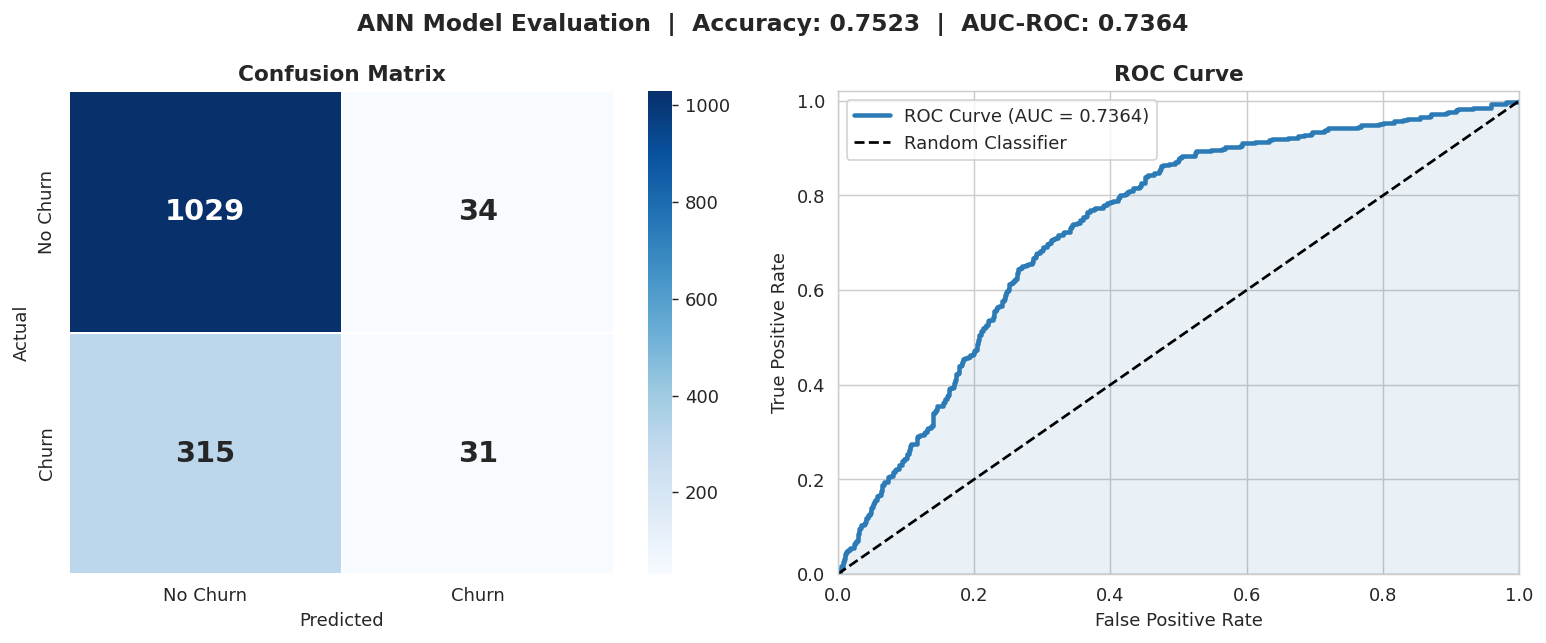


*Figure 6: Confusion Matrix (left) and ROC Curve (right)*

### Interpreting Results

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **Accuracy** | 0.7523 | Correct predictions over total |
| **AUC-ROC** | 0.7364 | Model's ability to distinguish classes |
| **Confusion Matrix** | TP/TN/FP/FN | Actual vs predicted churn counts |

---


<a id="12"></a>
## 12. Feature Importance (Permutation)


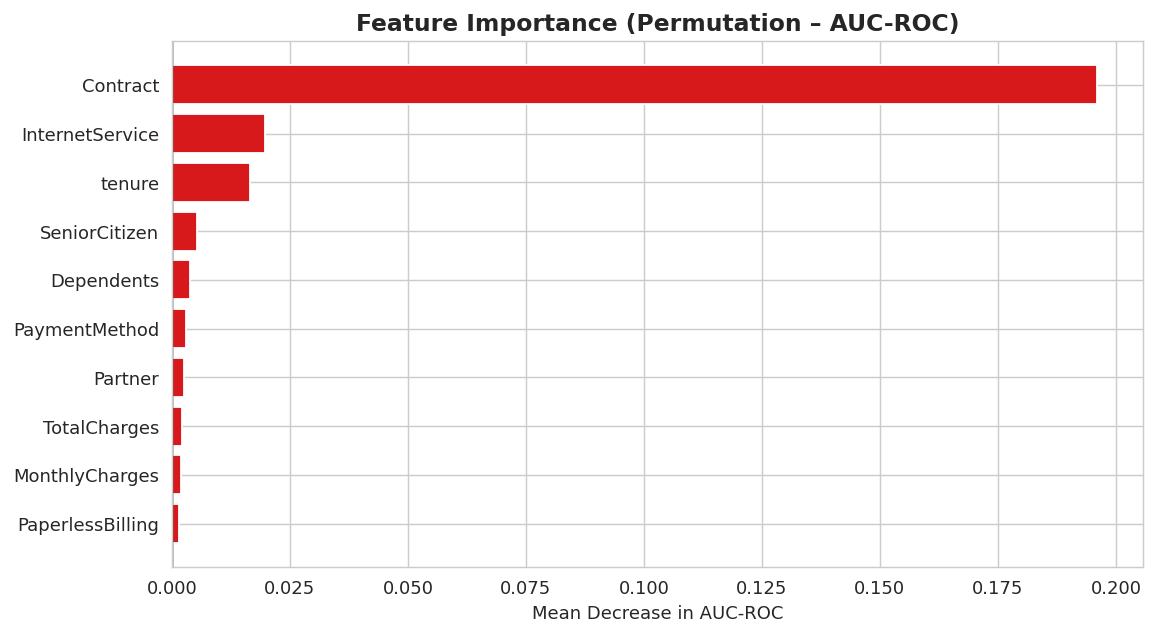


*Figure 7: Permutation-based feature importance – features that most affect AUC-ROC when shuffled*

Features with **higher positive importance** are more critical for the model's predictions. Shuffling them causes a larger drop in AUC-ROC, confirming their predictive power.

---


<a id="13"></a>
## 13. Conclusion

### Summary

| Step | Description |
|------|-------------|
| **Data** | Telco Customer Churn – 7,043 samples, 10 features |
| **Preprocessing** | Label encoding, StandardScaler, 80/20 stratified split |
| **Architecture** | Input(10) → Dense(64,ReLU) → Dense(32,ReLU) → Output(1,Sigmoid) |
| **Optimizer** | Adam with adaptive learning rate |
| **Regularization** | L2 penalty (α=0.0001) + Early Stopping |
| **Accuracy** | **0.7523** |
| **AUC-ROC** | **0.7364** |

### Key Takeaways
- ANNs are powerful for **non-linear classification** problems like churn prediction
- **Feature scaling** is mandatory for gradient-based ANN training
- **Early stopping** effectively prevents overfitting
- **Contract type** and **tenure** are the strongest churn predictors
- **Adam optimizer** converges faster than vanilla SGD

### Potential Improvements
- Class imbalance handling (SMOTE, class_weight)
- Hyperparameter tuning (GridSearchCV / Bayesian optimization)
- Deeper architectures or Dropout regularization
- Feature engineering (interaction terms, binning)

---
*End of Notebook*
